# Optimizing the Piezo Position

``` Pseudo
1. Get scanners current position
2. Set resolution (we know range will be 1 um in the xy plane)
3. Build the sequence, centered around the current position
4. For each position in sequence, go to that position and take an image
5. Calculate the total brightness for each image, and fit a gaussian distribution to the sequence
6. Plot
```

### Scanner Architecture: GUI to Hardware

- **For positioning**: ScannerGui → ScanningProbeLogic → NiScanningProbeInterfuse → **ni_ao** → Hardware
- **For scanning**: ScannerGui → ScanningProbeLogic → NiScanningProbeInterfuse → **ni_finite_sampling_io** → Hardware
- Interfuse selects appropriate hardware
Piezo stages: x, y, z axes
    - ao0 → x-axis
    - ao1 → y-axis  
    - ao2 → z-axis

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import cv2
import torch
import torch.nn.functional as F

## SPAD Configuration

In [2]:
spad = camera_SPC3
spad._NFrames = 1 
spad._apply_camera_settings()

## Building the Sequence

### Optimization Params
- resolution_x = 3 # pixels
- resolution_y = 3 # pixels
- scan_range_x = 1e-6 # units are in m; 1 micron for both x and y ensures pixel is centered on nv
- scan_range_y = 1e-6

In [3]:
resolution_x = 10 # pixels
resolution_y = 10 # pixels
scan_range_x = 1.0e-6 # meters
scan_range_y = 1.0e-6 # meters
arr_dim = 5 # what are the number of nv's in each row and column of the array

piezo = scanning_probe_logic
x_l_bound, x_u_bound = piezo.scanner_constraints.axes['x'].position.bounds
y_l_bound, y_u_bound = piezo.scanner_constraints.axes['y'].position.bounds

# Build sequence
curr_pos = piezo.scanner_position # make sure it's centered; maybe add some logic later to do a quick edge detection
start_x = curr_pos['x'] - scan_range_x / 2
start_y = curr_pos['y'] - scan_range_y / 2
sequence_x = np.linspace(start_x, start_x + scan_range_x, int(resolution_x))
sequence_y = np.linspace(start_y, start_y + scan_range_y, int(resolution_y))

# Check params
w, h = spad.get_size()
array_size_microns = 2 * arr_dim - 1 
pxl_per_micron_x = w / array_size_microns  # 32 pixels / 9 microns = 3.56 pxl/micron
pxl_per_micron_y = h / array_size_microns

if sequence_x[0] < x_l_bound or sequence_x[-1] > x_u_bound:
    raise ValueError(f"X scan range [{sequence_x[0]:.2e}, {sequence_x[-1]:.2e}] m exceeds scanner bounds [{x_l_bound:.2e}, {x_u_bound:.2e}] m")

if sequence_y[0] < y_l_bound or sequence_y[-1] > y_u_bound:
    raise ValueError(f"Y scan range [{sequence_y[0]:.2e}, {sequence_y[-1]:.2e}] m exceeds scanner bounds [{y_l_bound:.2e}, {y_u_bound:.2e}] m")

print(curr_pos)

{'x': 0.0001663354, 'y': 8.9127e-06, 'z': 0.0001043026}


## Sampling Images in the XY-Plane

### Position Dictionary
```
{'x': 0.0001729267, 'y': 2.8033e-05, 'z': 0.0001018735}
```

In [4]:
img_samples = np.zeros((resolution_x * resolution_y, h, w), dtype=np.float32)
pos_dict = {k: float(v) for k, v in curr_pos.items()}

idx = 0
for y_sample in sequence_y:
    for x_sample in sequence_x:
        pos_dict['x'] = float(x_sample)
        pos_dict['y'] = float(y_sample)
        
        position = piezo.set_target_position(pos_dict, move_blocking=True)
        
        frame = np.array(spad.start_single_acquisition()[0, 0, :, :])
        img_samples[idx] = np.flipud(frame)
        idx += 1
        print(f"Captured frame {idx}/{resolution_x * resolution_y}")

print(f"Final shape: {img_samples.shape}")

TypeError: 'NoneType' object is not subscriptable

## Calculating the Brightness Using a Kernel

In [ ]:
img_samples = np.nan_to_num(img_samples, 0)

def sum_array_batched(imgs, pxl_per_micron_x, pxl_per_micron_y):
    imgs = torch.from_numpy(imgs).float().unsqueeze(1)

    nv_size_x = int(pxl_per_micron_x)  # pixels per NV
    nv_size_y = int(pxl_per_micron_y)

    # Kernel stride
    spacing_x = int(2 * pxl_per_micron_x)  
    spacing_y = int(2 * pxl_per_micron_y)
    stride = (spacing_y, spacing_x)

    # Kernel = 1 micron NV box
    kernel = torch.ones((1, 1, nv_size_y, nv_size_x), dtype=imgs.dtype)

    out = F.conv2d(imgs, kernel, stride=stride, padding=0)
    brightness = out.squeeze(1).cpu().numpy()
    return brightness

nv_brightness = sum_array_batched(imgs=img_samples, pxl_per_micron_x=pxl_per_micron_x, pxl_per_micron_y=pxl_per_micron_y)

print(f"Original: {img_samples.shape}")
print(f"Array FOV: {array_size_microns} microns")
print(f"Pixels per micron: {pxl_per_micron_x:.2f}")
print(f"NV size: {int(pxl_per_micron_x)}x{int(pxl_per_micron_y)} pixels")
print(f"Result: {nv_brightness.shape}")

Original: (100, 32, 32)
Array FOV: 9 microns
Pixels per micron: 3.56
NV size: 3x3 pixels
Result: (100, 5, 5)


## Create Overlap Function and Fit Data - CHECK

In [ ]:
nv_brightness = np.sum(nv_brightness, axis=(1, 2)) # (resolution_y * resolution_x, 1)
nv_brightness = np.reshape(nv_brightness, (resolution_y, resolution_x)) # (resolution_y, resolution_x, 1)

Peak location: 0.00016733085200664542 1.04127e-05
A, C: 2572301781.268816 -2572278740.7512565
R-Squared: 0.764
RMSE: 626.460


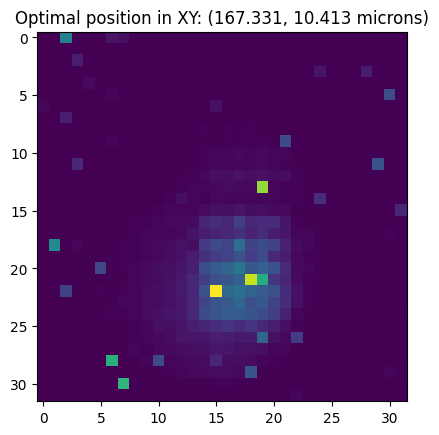

In [ ]:
# CHECK

def square_overlap_area(dx, dy):
    overlap_x = np.maximum(0.0, 1.0 - np.abs(dx))
    overlap_y = np.maximum(0.0, 1.0 - np.abs(dy))
    return overlap_x * overlap_y

def overlap_model(XY, amplitude, x_center, y_center, background):
    x, y = XY
    return (amplitude * square_overlap_area(x - x_center, y - y_center) + background).ravel()


X, Y = np.meshgrid(sequence_x, sequence_y, indexing="xy")

row_max, col_max = np.unravel_index(np.argmax(nv_brightness), nv_brightness.shape)

x_center_guess = X[row_max, col_max]
y_center_guess = Y[row_max, col_max]
background_guess = float(np.min(nv_brightness))
amplitude_guess = float(nv_brightness[row_max, col_max] - background_guess)

p0 = (
    amplitude_guess,
    x_center_guess,
    y_center_guess,
    background_guess,
)

bounds = (
    [0.0, sequence_x[0], sequence_y[0], -np.inf],
    [np.inf, sequence_x[-1], sequence_y[-1], np.inf]
) # A, x0, y0, C; constrains possible values for optimal position

popt, _ = curve_fit(
    overlap_model,
    (X, Y),
    nv_brightness.ravel(),
    p0=p0,
    bounds=bounds
)

A_fit, x0_fit, y0_fit, C_fit = popt

pred = A_fit * square_overlap_area(X - x0_fit, Y - y0_fit) + C_fit
resid = nv_brightness - pred

sse = float(np.sum(resid**2))
sst = float(np.sum((nv_brightness - np.mean(nv_brightness))**2))
r2 = 1.0 - (sse / sst) if sst > 0 else float("nan")
rmse = float(np.sqrt(np.mean(resid**2)))

pos_dict['x'], pos_dict['y'] = float(x0_fit), float(y0_fit)
position = piezo.set_target_position(pos_dict, move_blocking=True)
frame = np.array(spad.start_single_acquisition()[0, 0, :, :])
plt.title(f"Optimal position in XY: ({x0_fit*10**6:.3f}, {y0_fit*10**6:.3f} microns)")
plt.imshow(frame)

print("Peak location:", x0_fit, y0_fit)
print("A, C:", A_fit, C_fit)
print(f"R-Squared: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

## Plot Fit - CHECK

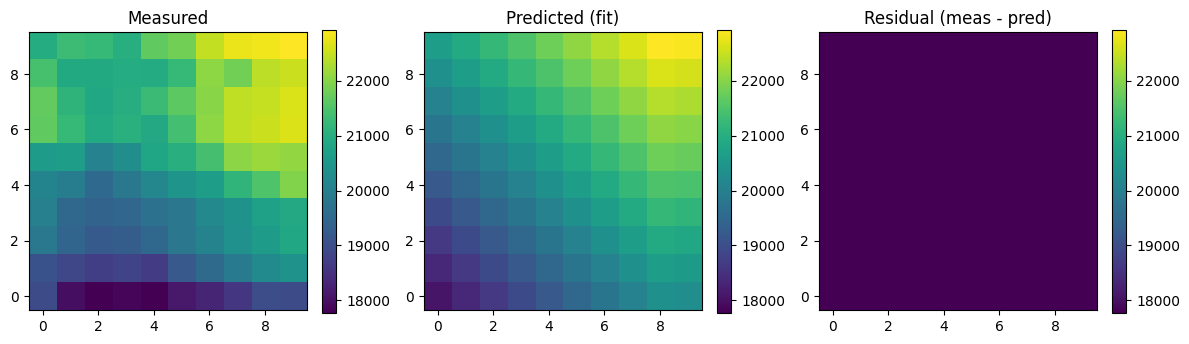

In [ ]:
plt.figure(figsize=(12, 4))

vmin = min(nv_brightness.min(), pred.min())
vmax = max(nv_brightness.max(), pred.max())

plt.subplot(1, 3, 1)
plt.title("Measured")
plt.imshow(nv_brightness, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(fraction=0.046)

plt.subplot(1, 3, 2)
plt.title("Predicted (fit)")
plt.imshow(pred, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(fraction=0.046)

plt.subplot(1, 3, 3)
plt.title("Residual (meas - pred)")
m = np.max(np.abs(resid))
plt.imshow(resid, origin="lower", vmin=-m, vmax=m)
plt.colorbar(fraction=0.046)

plt.tight_layout()
plt.show()


In [ ]:
def gaussian_2d(XY, amplitude, x_center, y_center, sigma_x, sigma_y, background):
    x, y = XY
    g = background + amplitude * np.exp(
        -(((x - x_center) ** 2) / (2 * sigma_x ** 2) +
          ((y - y_center) ** 2) / (2 * sigma_y ** 2))
    )
    return g.ravel()

X, Y = np.meshgrid(sequence_x, sequence_y, indexing="xy")
z = nv_brightness.astype(float)

row_max, col_max = np.unravel_index(np.argmax(z), z.shape)
x_center_guess = X[row_max, col_max]
y_center_guess = Y[row_max, col_max]
background_guess = float(np.min(z))
amplitude_guess = float(z[row_max, col_max] - background_guess)

scan_range_x = float(sequence_x.max() - sequence_x.min())
scan_range_y = float(sequence_y.max() - sequence_y.min())
sigma_x_guess = scan_range_x / 4.0 if scan_range_x > 0 else 1.0
sigma_y_guess = scan_range_y / 4.0 if scan_range_y > 0 else 1.0

p0 = (amplitude_guess, x_center_guess, y_center_guess, sigma_x_guess, sigma_y_guess, background_guess)

bounds = (
    [0.0, sequence_x.min(), sequence_y.min(), 1e-12, 1e-12, -np.inf],
    [np.inf, sequence_x.max(), sequence_y.max(), np.inf, np.inf,  np.inf],
)

popt, _ = curve_fit(
    gaussian_2d,
    (X, Y),
    z.ravel(),
    p0=p0,
    bounds=bounds
)

amplitude_fit, x_center_fit, y_center_fit, sigma_x_fit, sigma_y_fit, background_fit = popt

pred = (background_fit + amplitude_fit * np.exp(
    -(((X - x_center_fit) ** 2) / (2 * sigma_x_fit ** 2) +
      ((Y - y_center_fit) ** 2) / (2 * sigma_y_fit ** 2))
))

resid = z - pred

sse = float(np.sum(resid**2))
sst = float(np.sum((z - np.mean(z))**2))
r2 = 1.0 - (sse / sst) if sst > 0 else float("nan")
rmse = float(np.sqrt(np.mean(resid**2)))

print("Peak location:", x_center_fit, y_center_fit)
print("amplitude, background:", amplitude_fit, background_fit)
print("sigma_x, sigma_y:", sigma_x_fit, sigma_y_fit)
print(f"R-Squared: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

pos_dict["x"], pos_dict["y"] = float(x_center_fit), float(y_center_fit)
position = piezo.set_target_position(pos_dict, move_blocking=True)
frame = np.array(spad.start_single_acquisition()[0, 0, :, :])
frame = np.flipud(frame)
plt.title(f"Optimal position in XY: ({x_center_fit*1e6:.3f}, {y_center_fit*1e6:.3f} microns)")
plt.imshow(frame)
plt.show()

In [ ]:
plt.figure(figsize=(12, 4))

vmin = min(z.min(), pred.min())
vmax = max(z.max(), pred.max())

plt.subplot(1, 3, 1)
plt.title("Measured")
plt.imshow(z, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(fraction=0.046)

plt.subplot(1, 3, 2)
plt.title("Predicted (Gaussian fit)")
plt.imshow(pred, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(fraction=0.046)

plt.subplot(1, 3, 3)
plt.title("Residual (meas - pred)")
m = np.max(np.abs(resid))
plt.imshow(resid, origin="lower", vmin=-m, vmax=m)
plt.colorbar(fraction=0.046)

plt.tight_layout()
plt.show()

In [ ]:
print(pos_dict)

{'x': 0.00016733085200664542, 'y': 1.04127e-05, 'z': 0.0001044642}


In [ ]:
raise NotImplementedError("Interrupt Script")

## Scan Z-axis - CHECK

In [ ]:
resolution_z = 10 # pixels
curr_pos = piezo.scanner_position
scan_start_z = float(curr_pos['z']) - 0.000005 # m
scan_end_z = scan_start_z + 0.00001 #m
z_l_bound, z_u_bound = piezo.scanner_constraints.axes['z'].position.bounds

if scan_start_z < z_l_bound or scan_end_z > z_u_bound:
    raise ValueError(f"Z scan range [{scan_start_z:.2e}, {scan_end_z[-1]:.2e}] m exceeds scanner bounds [{x_l_bound:.2e}, {x_u_bound:.2e}] m")

w, h = spad.get_size()
array_size_microns = 2 * arr_dim - 1 
pxl_per_micron_x = w / array_size_microns  # 32 pixels / 9 microns = 3.56 pxl/micron
pxl_per_micron_y = h / array_size_microns

# Build sequence
sequence_z = np.linspace(scan_start_z, scan_end_z, int(resolution_z))

## Sampling Images along Z-axis

### Position Dictionary
```
{'x': 0.0001729267, 'y': 2.8033e-05, 'z': 0.0001018735}
```

In [ ]:
img_samples_Z = np.zeros((resolution_z, h, w), dtype=np.float32)
pos_dict = {k: float(v) for k, v in curr_pos.items()}

for z_sample in sequence_z:
    pos_dict['z'] = float(z_sample)

    position = piezo.set_target_position(pos_dict, move_blocking=True)
    
    frame = np.array(spad.start_single_acquisition()[0, 0, :, :])
    np.append(img_samples_Z, np.flipud(frame))
    # print(f"Captured frame {idx}/{resolution_x * resolution_y}")

print(f"Final shape: {img_samples_Z.shape}")

Final shape: (10, 32, 32)


## Calculating the Brightness Using a Kernel

In [ ]:
img_samples_Z = np.nan_to_num(img_samples_Z, 0)

nv_brightness_Z = sum_array_batched(imgs=img_samples_Z, pxl_per_micron_x=pxl_per_micron_x, pxl_per_micron_y=pxl_per_micron_y)

print(f"Original: {img_samples_Z.shape}")
print(f"Array FOV: {array_size_microns} microns")
print(f"Pixels per micron: {pxl_per_micron_x:.2f}")
print(f"NV size: {int(pxl_per_micron_x)}x{int(pxl_per_micron_y)} pixels")
print(f"Result: {nv_brightness_Z.shape}")

Original: (10, 32, 32)
Array FOV: 9 microns
Pixels per micron: 3.56
NV size: 3x3 pixels
Result: (10, 5, 5)


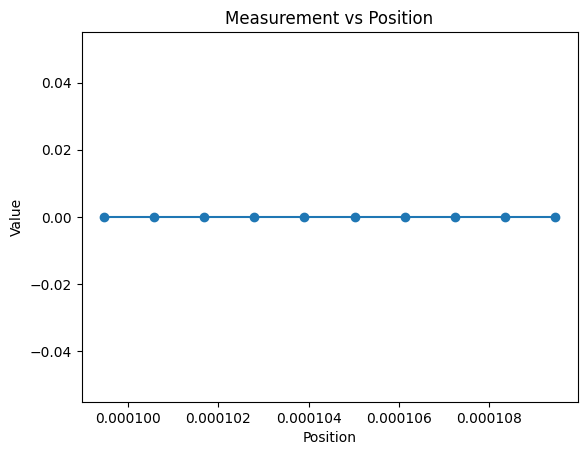

In [ ]:
nv_brightness_Z = np.sum(nv_brightness_Z, axis=(1, 2)) # (resolution_z, 1)
plt.plot(sequence_z, nv_brightness_Z, marker='o', linestyle='-')
plt.xlabel("Position")
plt.ylabel("Value")
plt.title("Measurement vs Position")
plt.show()

## Fitting to a Gaussian Distribution

In [ ]:
def gaussian(x, amp, mu, sigma, offset):
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2)) + offset

bounds_z = (
    [0.0, sequence_x[0], sequence_y[0], -np.inf], 
    [np.inf, sequence_x[-1], sequence_y[-1], np.inf]
)

# initial guesses matter
p0 = [
    nv_brightness_Z.max() - nv_brightness_Z.min(), # amplitude
    sequence_z[np.argmax(nv_brightness_Z)], # center
    np.std(sequence_z), # width
    nv_brightness_Z.min() # offset
]
print(p0)

popt, _ = curve_fit(gaussian, sequence_z, nv_brightness_Z, p0=p0, bounds=bounds_z)

# sse = float(np.sum(resid**2))
# sst = float(np.sum((nv_brightness - np.mean(nv_brightness))**2))
# r2 = 1.0 - (sse / sst) if sst > 0 else float("nan")
# rmse = float(np.sqrt(np.mean(resid**2)))
A_fit, z_fit, sigma, C_fit = popt
pos_dict['z'] = float(z_fit)
position = piezo.set_target_position(pos_dict, move_blocking=True)

[np.float32(0.0), np.float64(9.94642e-05), np.float64(3.1914236925211248e-06), np.float32(0.0)]


ValueError: Initial guess is outside of provided bounds

## Plot Fit

In [ ]:
x_axis = np.linspace(min(sequence_z), max(sequence_z), 500)
y_axis = gaussian(x_axis, *popt)

plt.scatter(sequence_z, nv_brightness_Z, label="Data")
plt.plot(x_axis, y_axis, label=f"Optimal Z Position for XY = ({pos_dict["x"]}, {pos_dict["y"]}")
plt.xlabel("Z Position")
plt.ylabel("Brightness")
plt.legend()
plt.show()

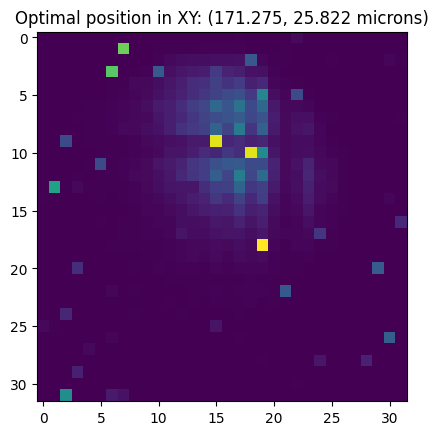

In [ ]:
# SAVE IN CASE NEED TO FIT XZ OR XY
def gaussian_2d(xy, amplitude, xo, yo, sigma_x, sigma_y, offset):
    x, y = xy
    g = offset + amplitude * np.exp(
        -(((x - xo) ** 2) / (2 * sigma_x ** 2) + ((y - yo) ** 2) / (2 * sigma_y ** 2))
    )

    # add distance from center penalty
    return g.ravel()



initial_guess = (
    np.max(nv_brightness),  # amplitude
    curr_pos['x'],  # xo (center x)
    curr_pos['y'],  # yo (center y)
    scan_range_x / 4,  # sigma_x
    scan_range_y / 4,  # sigma_y
    np.min(nv_brightness)  # offset
)

position_opt, _ = curve_fit(
    gaussian_2d, 
    (X.ravel(), Y.ravel()), 
    nv_brightness.ravel(), 
    p0=initial_guess
)

amplitude, xo, yo, sigma_x, sigma_y, offset = position_opt

fit = gaussian_2d((X, Y), *position_opt).reshape(resolution_x, resolution_y)

pos_dict['x'], pos_dict['y'] = float(xo), float(yo)
position = piezo.set_target_position(pos_dict, move_blocking=True)
frame = np.array(spad.start_single_acquisition()[0, 0, :, :])
frame = np.flipud(frame)
plt.title(f"Optimal position in XY: ({xo*10**6:.3f}, {yo*10**6:.3f} microns)")
plt.imshow(frame)